# LightGBM Sybil Detector — LayerZero

Reproduces the tuned LightGBM model.

**Configuration**: `num_leaves`, `learning_rate`, `subsample`, and `reg_lambda` selected on validation
by `05_hyperparameter_search` (printed in section 5); `subsample_freq=1`, `colsample_bytree=0.8`;
3-seed ensemble (seeds 42, 123, 456).

**Key gotchas vs XGBoost**:
- `num_leaves` (not `max_depth`) is the primary capacity parameter
- `subsample_freq=1` is **required** for bagging to activate
- `reg_lambda` defaults to 0 in LightGBM (vs 1 in XGBoost) — must set explicitly

**Results**: test metrics are printed in section 6 and saved to `results/02_lightgbm_<split>.json`;
`06_split_comparison` tabulates both splits.

## 1. Setup

In [12]:
# Install required packages (run once)
# !pip install xgboost lightgbm scikit-learn pandas numpy matplotlib

In [13]:
import os, time, warnings, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    precision_recall_curve, roc_curve, auc,
    f1_score, precision_score, recall_score,
    confusion_matrix, classification_report,
    brier_score_loss, average_precision_score
)

import sybil_pipeline as sp

warnings.filterwarnings('ignore')
SEED = sp.SEED

In [14]:
# ── Set this to the folder containing all data files ──────────
DATA_DIR = './data'   # <-- adjust if needed

# 'group'  = stratified group split by funding cluster (revision default)
# 'random' = address-level split used in the original paper
SPLIT_METHOD = os.environ.get('SPLIT_METHOD', 'group')

FEATS = sp.FEATS   # 62 model features (defined in sybil_pipeline.py)
print(f'Split method: {SPLIT_METHOD}  |  {len(FEATS)} features')

DATA_DIR : ./data
Features : 63


## 2. Data Loading

In [15]:
# ── Build the master feature table (steps 1-7; see 00_data_pipeline) ──
df, tfm, labeled_anchors = sp.build_master_df(DATA_DIR)

[1] L0 features: 434,786 addresses, 55 cols  (8.3s)
[2] Gas provision: 604,661 mappings  (3.3s)
[3] Labeled anchors: 3,698  (11.3s)
[4] Tree features merged: 434,787 rows, 89 cols  (6.0s)
[5] CEX/DEX merged: 434,787 rows, 91 cols  (2.9s)
[6] Labels: Sybil=18,211 (4.19%)  (1.5s)
[7] Chain features: mean=1.88, max=504  (2.7s)
All 63 features present ✓


## 3. Train / Validation / Test Split

In [16]:
# ── Train / Val / Test split + minority upsampling ────────────
# 49 / 21 / 30 partitions. With SPLIT_METHOD='group', no funding group
# spans two partitions (asserted inside sp.make_splits).
S = sp.make_splits(df, FEATS, method=SPLIT_METHOD, seed=SEED)
X_train, y_train = S['X_train'], S['y_train']
X_val,   y_val   = S['X_val'],   S['y_val']
X_test,  y_test  = S['X_test'],  S['y_test']

print(sp.split_summary(df, S).to_string(index=False))
print(f'Train after upsampling: {len(X_train):,} rows ({y_train.mean()*100:.1f}% Sybil)\n')
leak = sp.leakage_report(df, S)

Train (balanced) : 408,242  (50.0% Sybil)
Validation       : 91,305   (4.19% Sybil)
Test             : 130,437  (4.19% Sybil)


## 4. Evaluation Helpers

In [17]:
# ── Evaluation helpers ────────────────────────────────────────
def optimal_threshold(y_true, probs):
    """Find threshold that maximises F1 on the given set."""
    prec, rec, thresholds = precision_recall_curve(y_true, probs)
    f1 = np.where((prec + rec) > 0, 2 * prec * rec / (prec + rec), 0)
    return float(thresholds[np.argmax(f1[:-1])])

def evaluate(name, val_probs, test_probs, y_val, y_test, threshold=None):
    """Evaluate model at optimal val threshold, report test metrics."""
    thr = threshold if threshold is not None else optimal_threshold(y_val, val_probs)
    y_pred = (test_probs >= thr).astype(int)
    fpr, tpr, _ = roc_curve(y_test, test_probs)
    prc, rec, _ = precision_recall_curve(y_test, test_probs)
    results = dict(
        name      = name,
        threshold = thr,
        precision = precision_score(y_test, y_pred, zero_division=0),
        recall    = recall_score(y_test, y_pred,    zero_division=0),
        f1        = f1_score(y_test, y_pred,         zero_division=0),
        auroc     = auc(fpr, tpr),
        ap        = average_precision_score(y_test, test_probs),
        brier     = brier_score_loss(y_test, test_probs),
        fpr=fpr, tpr=tpr, prc=prc, rec_c=rec,
    )
    print(f'  Threshold : {thr:.4f}')
    print(f'  Precision : {results["precision"]:.4f}')
    print(f'  Recall    : {results["recall"]:.4f}')
    print(f'  F1        : {results["f1"]:.4f}')
    print(f'  AUROC     : {results["auroc"]:.4f}')
    print(f'  Avg Prec  : {results["ap"]:.4f}')
    print(f'  Brier     : {results["brier"]:.4f}')
    print(classification_report(y_test, y_pred, digits=4))
    return results

def plot_curves(results_list):
    """Plot ROC and PR curves for one or more models."""
    colors = ['#1565C0','#2E7D32','#B71C1C','#6A1B9A','#E65100']
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for r, c in zip(results_list, colors):
        axes[0].plot(r['fpr'], r['tpr'], color=c, lw=2,
                     label=f"{r['name']}  AUC={r['auroc']:.4f}")
        axes[1].plot(r['rec_c'], r['prc'], color=c, lw=2,
                     label=f"{r['name']}  AP={r['ap']:.4f}")
    axes[0].plot([0,1],[0,1],'k--',alpha=0.3,lw=1)
    axes[0].set(xlabel='FPR', ylabel='TPR', title='ROC Curve')
    axes[0].legend(fontsize=9); axes[0].grid(alpha=0.2)
    axes[1].set(xlabel='Recall', ylabel='Precision', title='Precision-Recall Curve')
    axes[1].legend(fontsize=9, loc='upper right'); axes[1].grid(alpha=0.2)
    plt.tight_layout(); plt.show()

## 5. Train LightGBM (3-Seed Ensemble)

In [22]:
from lightgbm import LGBMClassifier
import lightgbm as lgb_lib

# Key differences from XGBoost:
#   num_leaves  instead of max_depth  (leaf-wise growth)
#   subsample_freq=1 required to activate bagging
#   reg_lambda defaults to 0 in LightGBM (1 in XGBoost); searched over {0, 1}

# ── Hyperparameters: selected on validation by 05_hyperparameter_search ──
_, LGBM_SELECTED = sp.load_selected_params()
LGBM_PARAMS = dict(
    n_estimators      = 5000,
    subsample_freq    = 1,        # REQUIRED to activate bagging (default=0 = off)
    colsample_bytree  = 0.8,      # feature_fraction
    random_state      = 42,
    verbose           = -1,
    n_jobs            = sp.N_JOBS,
    **LGBM_SELECTED,              # num_leaves, learning_rate, subsample, reg_lambda
)
print('LightGBM params:', LGBM_PARAMS)

SEEDS = [42, 123, 456]
val_probs_list  = []
test_probs_list = []
rounds = []

for seed in SEEDS:
    print(f'Training seed={seed}...', flush=True)
    t0 = time.time()
    model = LGBMClassifier(**{**LGBM_PARAMS, 'random_state': seed})
    model.fit(X_train, y_train,
              eval_set=[(X_val, y_val)],
              callbacks=[lgb_lib.early_stopping(50, verbose=False),
                         lgb_lib.log_evaluation(-1)])
    rounds.append(int(model.best_iteration_))
    val_probs_list.append(model.predict_proba(X_val)[:,1])
    test_probs_list.append(model.predict_proba(X_test)[:,1])
    print(f'  best_iteration={model.best_iteration_}  time={time.time()-t0:.1f}s')

lgbm_val_probs  = np.mean(val_probs_list,  axis=0)
lgbm_test_probs = np.mean(test_probs_list, axis=0)
print('\nEnsemble probabilities computed.')

Training seed=42...
  best_iteration=338  time=57.3s
Training seed=123...
  best_iteration=328  time=189.7s
Training seed=456...
  best_iteration=329  time=113.8s

Ensemble probabilities computed.


## 6. Evaluate on Test Set

=== LightGBM 3-Seed Ensemble — Test Set Results ===
  Threshold : 0.5936
  Precision : 0.7403
  Recall    : 0.7340
  F1        : 0.7371
  AUROC     : 0.9764
  Avg Prec  : 0.8005
  Brier     : 0.0179
              precision    recall  f1-score   support

           0     0.9884    0.9887    0.9886    124974
           1     0.7403    0.7340    0.7371      5463

    accuracy                         0.9781    130437
   macro avg     0.8643    0.8614    0.8628    130437
weighted avg     0.9780    0.9781    0.9780    130437



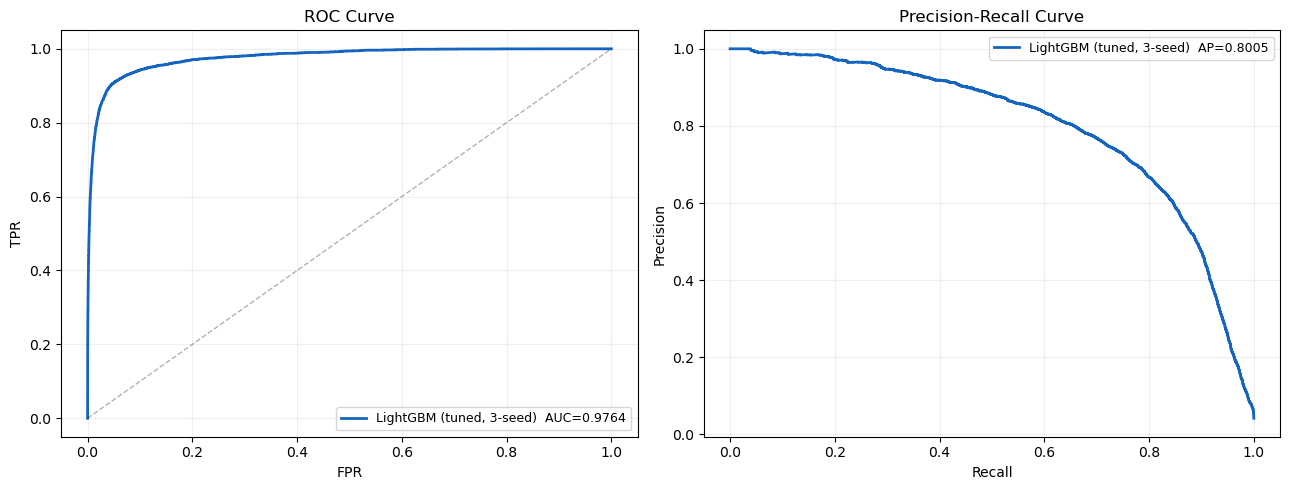

In [23]:
print('=== LightGBM 3-Seed Ensemble — Test Set Results ===')
lgbm_results = evaluate('LightGBM (tuned, 3-seed)',
                         lgbm_val_probs, lgbm_test_probs, y_val, y_test)
plot_curves([lgbm_results])

## 7. Feature Importances

Top 20 features (normalized Gini gain):
                          Feature  NormGain
                  l0_tx_time_span  0.219767
             l0_avg_stargate_swap  0.061829
              num_transactions_in  0.058781
               n_l0_source_chains  0.049984
             earliest_tx_block_in  0.049732
            n_l0_source_contracts  0.048624
                 max_tx_value_out  0.046011
              earliest_l0_tx_time  0.045042
                latest_l0_tx_time  0.041576
       gas_provision_block_number  0.040726
           tx_value_per_block_out  0.033470
                     time_span_in  0.028068
                  min_tx_value_in  0.027961
    n_l0_project_per_source_chain  0.024905
                    n_l0_projects  0.015659
provider_min_gas_provision_amount  0.015197
                 provider_fan_out  0.013085
                 min_tx_value_out  0.011232
provider_avg_gas_provision_amount  0.011072
      l0_to_eth_max_stargate_swap  0.010670


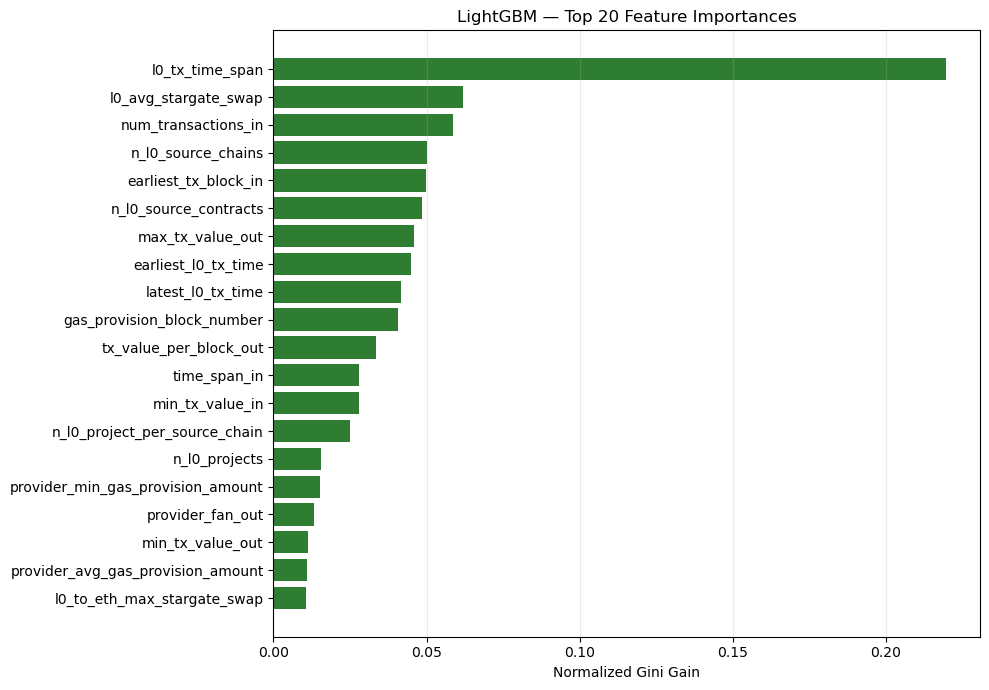

In [24]:
# ── Feature importance (last trained model, gain-based) ───────
gains = model.booster_.feature_importance(importance_type='gain')
total = gains.sum()
imp_df = pd.DataFrame({'Feature': FEATS, 'NormGain': gains / total})
imp_df = imp_df.sort_values('NormGain', ascending=False).reset_index(drop=True)
print('Top 20 features (normalized Gini gain):')
print(imp_df.head(20).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 7))
top20 = imp_df.head(20)
ax.barh(top20['Feature'][::-1], top20['NormGain'][::-1], color='#2E7D32')
ax.set(xlabel='Normalized Gini Gain',
       title='LightGBM — Top 20 Feature Importances')
ax.grid(axis='x', alpha=0.25)
plt.tight_layout(); plt.show()

## 8. Operating Point Table

In [25]:
# ── Operating point table ─────────────────────────────────────
n_sybil = int(y_test.sum()); n_clean = len(y_test) - n_sybil
print(f'\nTest set: {len(y_test):,} total | {n_sybil:,} Sybil | {n_clean:,} Non-Sybil\n')
print(f'  {"Threshold":<10} {"Precision":<11} {"Recall":<10} {"F1":<9} {"Flagged":<11} {"False+"}')
print('-'*65)
for t in [0.95, 0.90, 0.85, 0.80, 0.75, 0.70, round(lgbm_results["threshold"], 2), 0.50]:
    y_pred = (lgbm_test_probs >= t).astype(int)
    if y_pred.sum() == 0: continue
    tp_ = int(((y_pred==1)&(y_test==1)).sum()); fp_ = int(((y_pred==1)&(y_test==0)).sum())
    p = tp_/(tp_+fp_); r = tp_/n_sybil; f1v = 2*p*r/(p+r) if p+r>0 else 0
    mark = ' ←opt' if abs(t - lgbm_results['threshold']) < 0.03 else ''
    print(f'  {t:<10.2f} {p:<11.4f} {r:<10.4f} {f1v:<9.4f} {y_pred.sum():<11,} {fp_:,}{mark}')


Test set: 130,437 total | 5,463 Sybil | 124,974 Non-Sybil

  Threshold  Precision   Recall     F1        Flagged     False+
-----------------------------------------------------------------
  0.95       0.8752      0.5171     0.6501    3,228       403
  0.90       0.8441      0.5869     0.6924    3,798       592
  0.85       0.8185      0.6240     0.7081    4,165       756
  0.80       0.8029      0.6533     0.7204    4,445       876
  0.75       0.7842      0.6753     0.7257    4,704       1,015
  0.70       0.7704      0.6976     0.7322    4,947       1,136
  0.59       0.7395      0.7359     0.7377    5,436       1,416 ←opt
  0.50       0.7127      0.7615     0.7363    5,837       1,677


## Save Results

Scalar metrics go to `results/<notebook>_<split>.json` with the code commit, so every number in the paper can be traced to one run.

In [ ]:
sp.save_results([lgbm_results], '02_lightgbm', SPLIT_METHOD, leakage=leak,
                extra=dict(params=LGBM_SELECTED, rounds=rounds))

# ── Test predictions (read by 06_split_comparison for per-category metrics) ──
os.makedirs('output', exist_ok=True)
pred = pd.DataFrame({'addr': df.loc[S['idx_test'], 'addr'].to_numpy(),
                     'category': df.loc[S['idx_test'], 'category'].to_numpy(),
                     'y': y_test.to_numpy(), 'prob_lgbm': lgbm_test_probs})
pred.to_parquet(f'output/pred_02_lightgbm_{SPLIT_METHOD}.parquet', index=False)
print(f'Saved output/pred_02_lightgbm_{SPLIT_METHOD}.parquet ({len(pred):,} rows)')